In [1]:
import os
import pandas as pd
import pickle
import string
import re
import seaborn as sns

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt


In [2]:
en_stopwords = stopwords.words('english')

In [3]:
def preprocess_text(text):
    text = str(text).lower()
    
    text = re.sub(r'<.*?>', ' ', text) # Menghapus HTML tags
    text = re.sub(r'http\S+|www\S+|https\S+', ' ', text, flags=re.MULTILINE) # Menghapus URL
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # Menghapus karakter khusus dan angka (hanya sisakan huruf)
    text = re.sub(r'[^\w\s]', ' ', text)  # hapus punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # normalisasi spasi

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in en_stopwords]
    
    return " ".join(tokens)

In [4]:
train_df     = pd.read_csv('./train toxic comment.csv')
test_df      = pd.read_csv('test.csv')
 
print(f"Train shape : {train_df.shape}")
print(f"Test  shape : {test_df.shape}")
print("\nSample train data:")
train_df.head()

Train shape : (159571, 8)
Test  shape : (153164, 2)

Sample train data:


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [5]:
train_df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [6]:
target_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

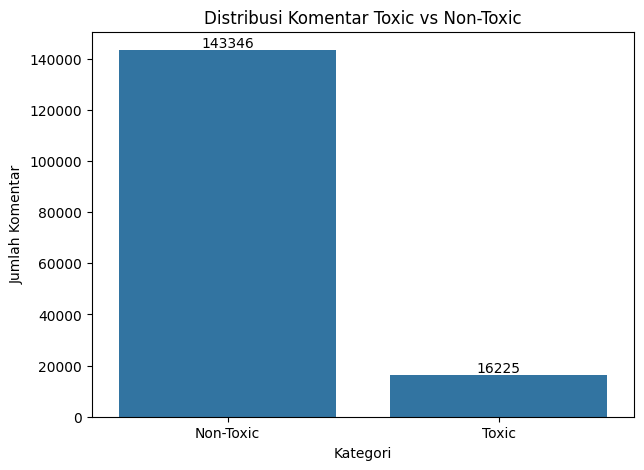

In [7]:
toxic_count = (train_df[target_cols].sum(axis=1) > 0).sum()

non_toxic_count = (train_df[target_cols].sum(axis=1) == 0).sum()

# Data visualisasi
labels = ['Non-Toxic', 'Toxic']
counts = [non_toxic_count, toxic_count]

# Plot
plt.figure(figsize=(7,5))

sns.barplot(
    x=labels,
    y=counts
)

# Judul
plt.title('Distribusi Komentar Toxic vs Non-Toxic')

# Label sumbu
plt.xlabel('Kategori')
plt.ylabel('Jumlah Komentar')

# Tambahkan angka di atas batang
for i, v in enumerate(counts):
    plt.text(i, v + 1000, str(v), ha='center')

plt.show()

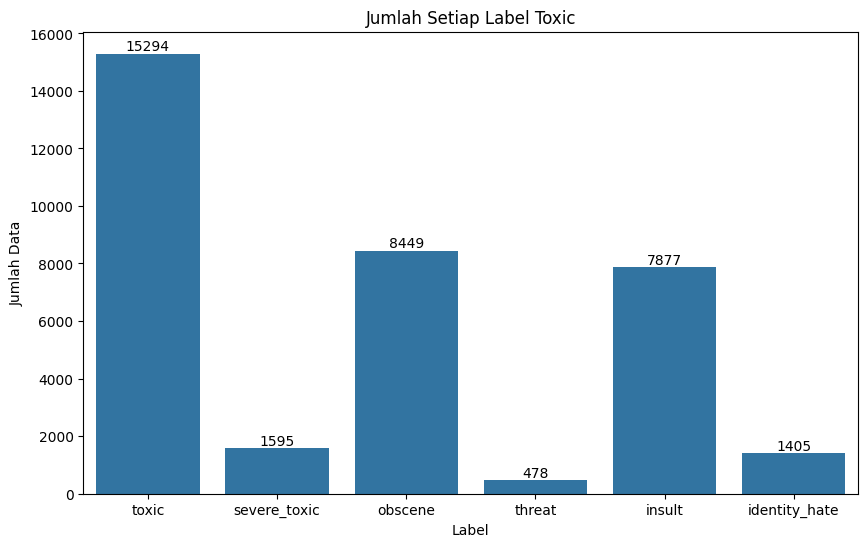

In [8]:
label_counts = train_df[target_cols].sum()

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x=label_counts.index,
    y=label_counts.values
)

plt.title('Jumlah Setiap Label Toxic')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')

# Tambahkan angka di atas bar
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 100, str(v), ha='center')

plt.show()

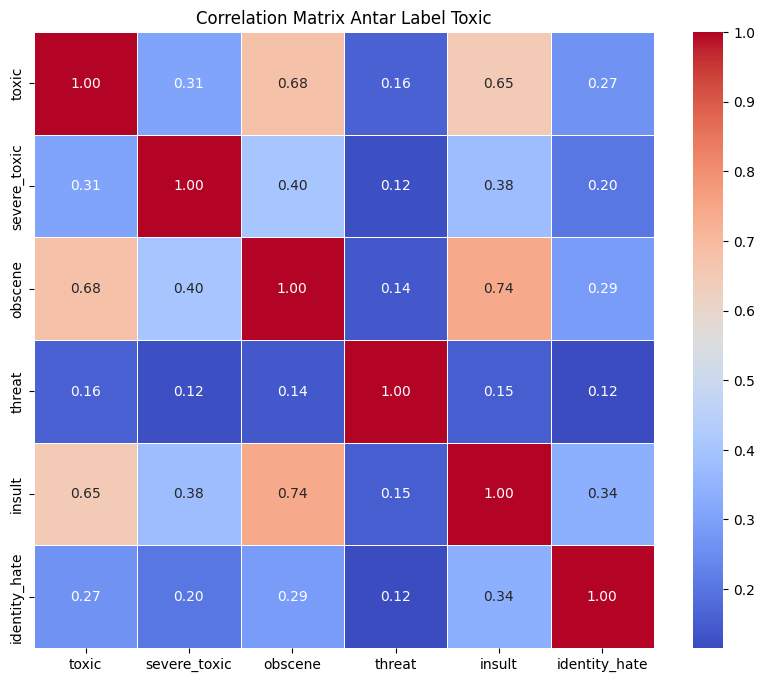

In [9]:
# Correlation Matrix
corr_matrix = train_df[target_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix Antar Label Toxic')
plt.show()

In [10]:
print("\nMemulai Preprocessing Teks pada Data Train...")
train_df['clean_text'] = train_df['comment_text'].fillna("").apply(preprocess_text)

print("Memulai Preprocessing Teks pada Data Test...")
test_df['clean_text'] = test_df['comment_text'].fillna("").apply(preprocess_text)


Memulai Preprocessing Teks pada Data Train...
Memulai Preprocessing Teks pada Data Test...


In [11]:
print(train_df['clean_text'].isna().sum())
print(test_df['clean_text'].isna().sum())

0
0


In [12]:
X = train_df['clean_text']
y = train_df[target_cols]

In [13]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
tfidf = TfidfVectorizer(max_features=10000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(test_df['clean_text'])

In [15]:
models = {
    "Naive Bayes": MultiOutputClassifier(MultinomialNB()),
    "Logistic Regression": MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')),
    "SVM (Linear)": MultiOutputClassifier(LinearSVC(random_state=42, dual="auto", class_weight='balanced')),
    "Random Forest": MultiOutputClassifier(RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1, class_weight='balanced'))
}

for name, model in models.items():
    print(f"\n" + "="*50)
    print(f"--- Proses Training: {name} ---")
    
    # Proses Training
    model.fit(X_train_tfidf, y_train)
    
    # Prediksi pada data validasi
    y_pred = model.predict(X_val_tfidf)
    
    accuracy = accuracy_score(y_val, y_pred)
    print(f"\nAccuracy: {accuracy:.4f}")

    # Evaluasi Hasil
    print(f"\nClassification Report untuk {name}:")
    print(classification_report(y_val, y_pred, target_names=target_cols, zero_division=0))


--- Proses Training: Naive Bayes ---

Accuracy: 0.9125

Classification Report untuk Naive Bayes:
               precision    recall  f1-score   support

        toxic       0.92      0.52      0.67      3056
 severe_toxic       0.69      0.10      0.17       321
      obscene       0.90      0.51      0.65      1715
       threat       0.00      0.00      0.00        74
       insult       0.83      0.42      0.56      1614
identity_hate       0.69      0.03      0.06       294

    micro avg       0.89      0.45      0.60      7074
    macro avg       0.67      0.26      0.35      7074
 weighted avg       0.87      0.45      0.58      7074
  samples avg       0.05      0.04      0.04      7074


--- Proses Training: Logistic Regression ---

Accuracy: 0.8631

Classification Report untuk Logistic Regression:
               precision    recall  f1-score   support

        toxic       0.61      0.86      0.71      3056
 severe_toxic       0.25      0.85      0.39       321
      obscene 


CONFUSION MATRIX - Naive Bayes


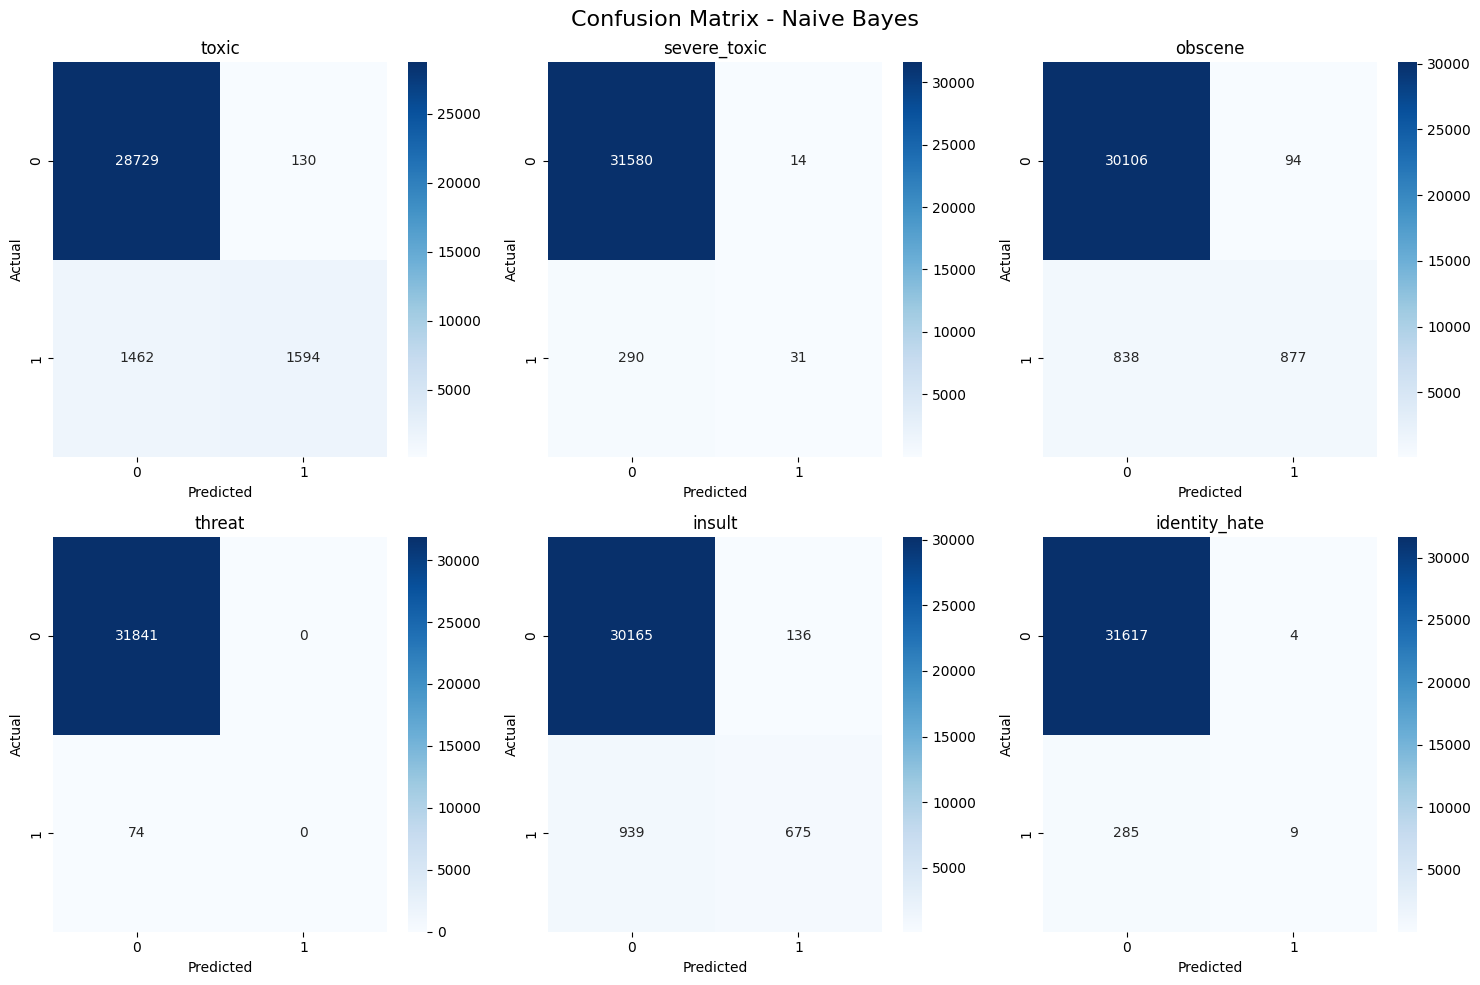


CONFUSION MATRIX - Logistic Regression


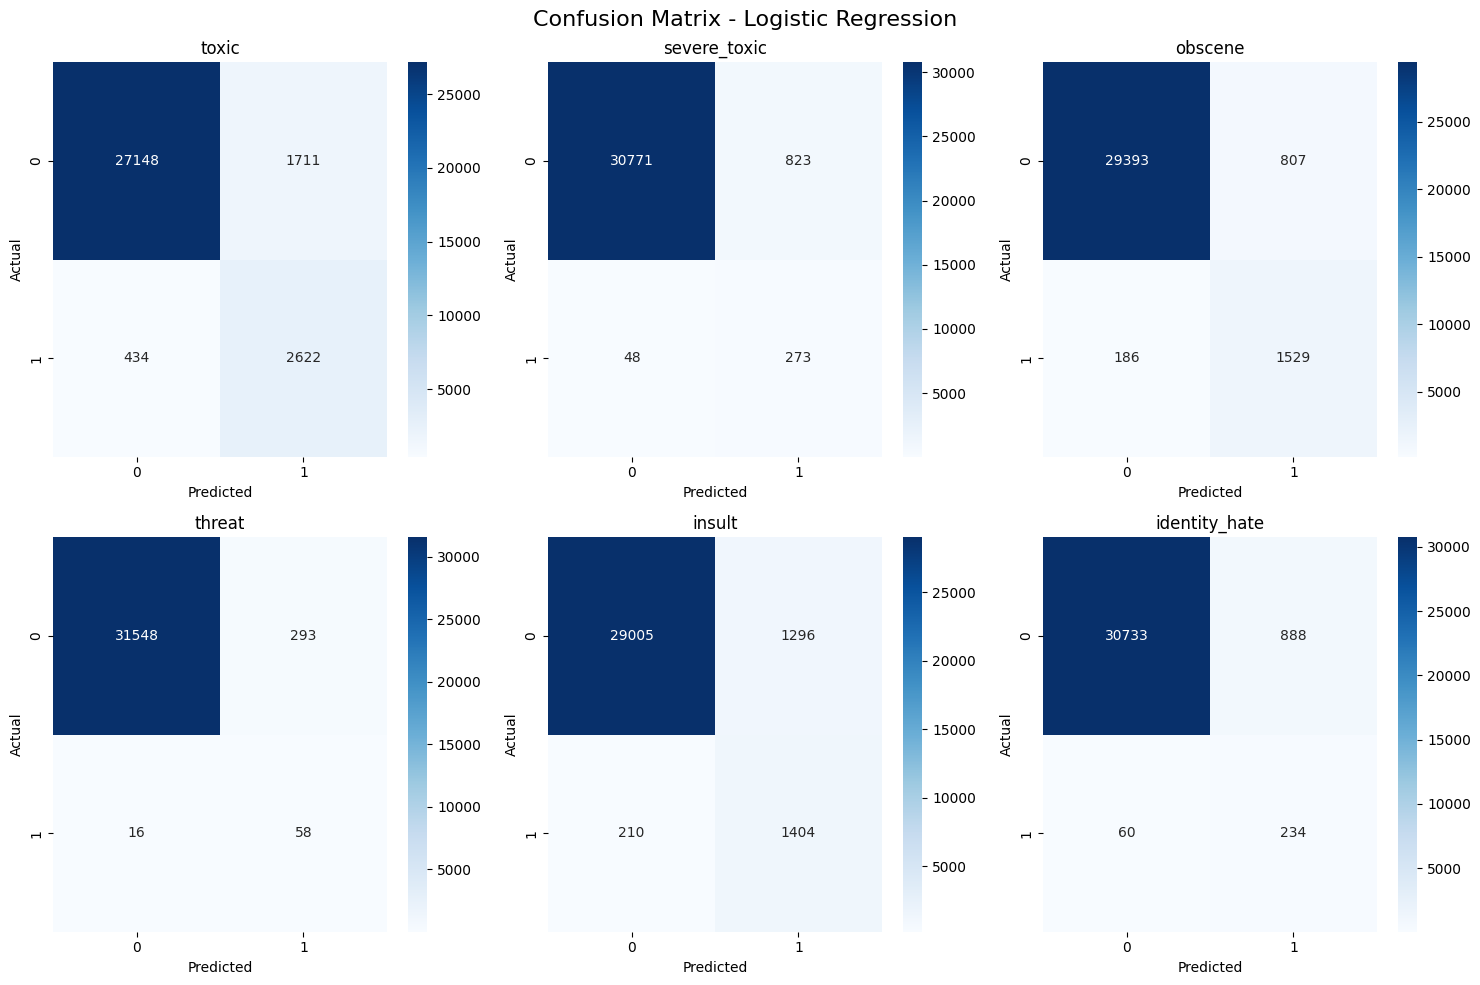


CONFUSION MATRIX - SVM (Linear)


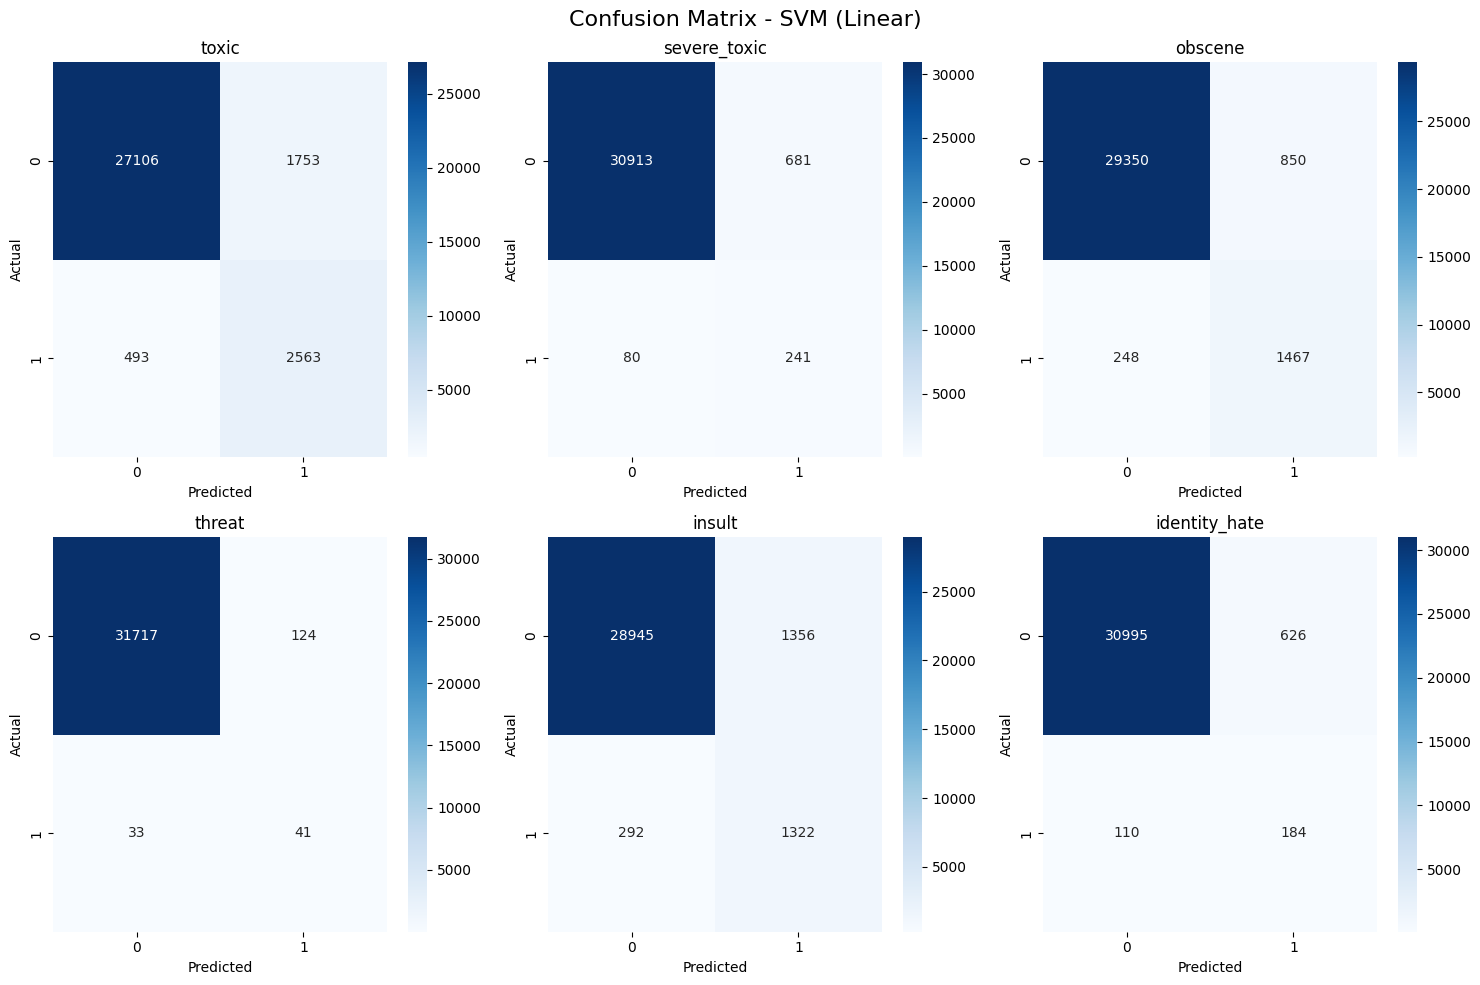


CONFUSION MATRIX - Random Forest


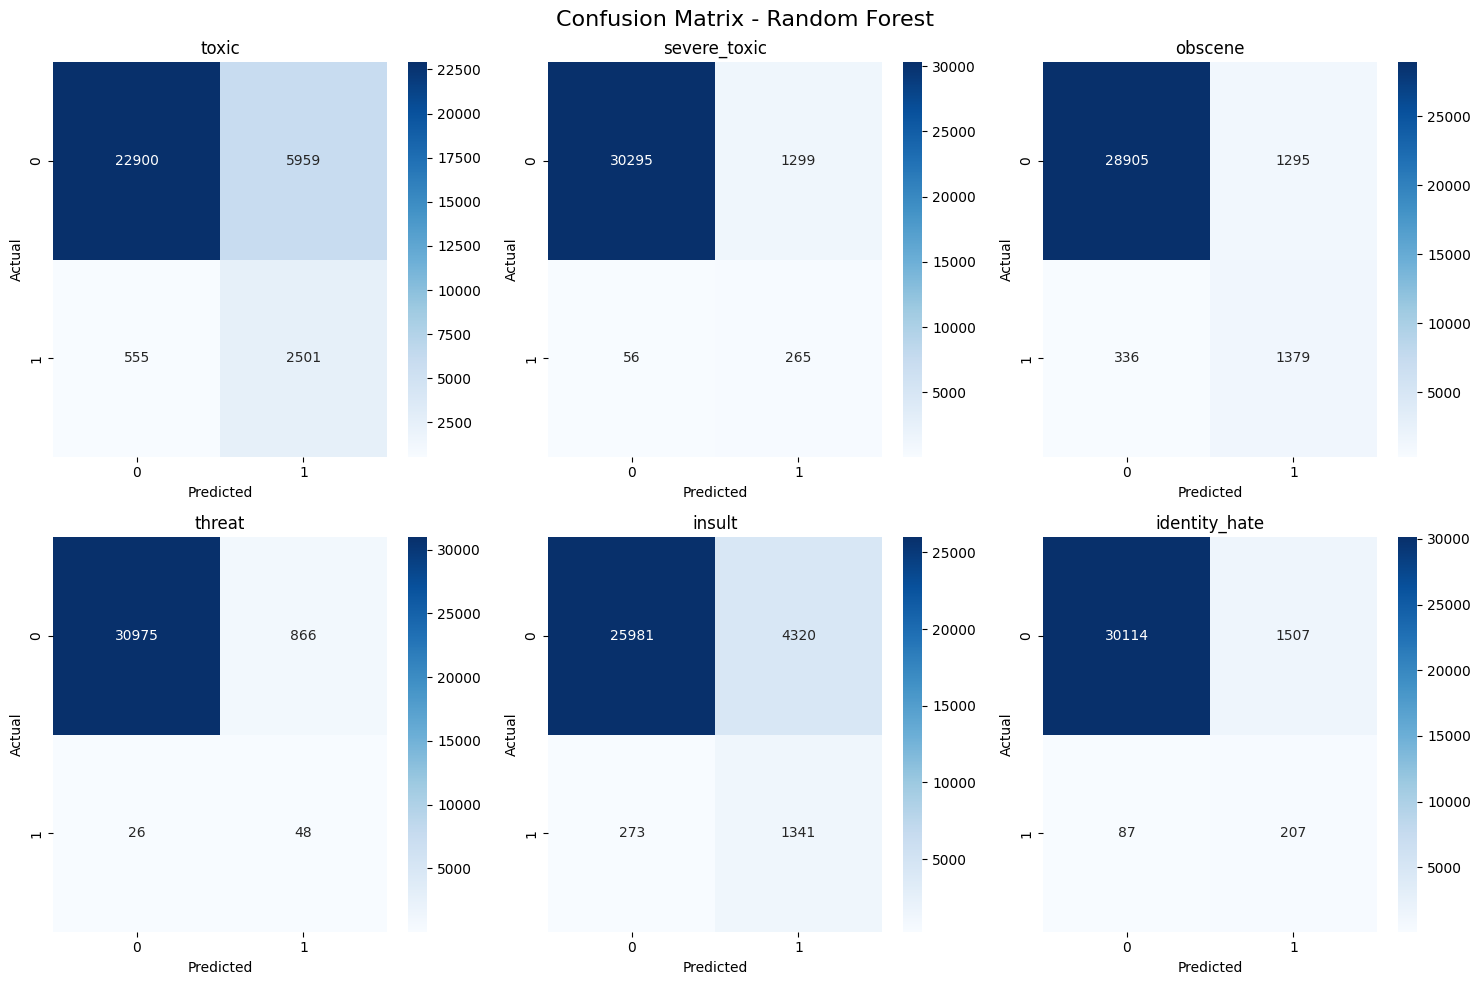

In [22]:
for model_name, model in models.items():

    print(f"\n{'='*60}")
    print(f"CONFUSION MATRIX - {model_name}")
    print(f"{'='*60}")

    # Prediksi
    y_pred = model.predict(X_val_tfidf)

    # Subplot
    fig, axes = plt.subplots(2, 3, figsize=(15,10))
    axes = axes.flatten()

    # Loop setiap label
    for i, label in enumerate(target_cols):

        # Buat confusion matrix
        cm = confusion_matrix(
            y_val[label],
            y_pred[:, i]
        )

        # Heatmap
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=axes[i]
        )

        # Judul
        axes[i].set_title(f'{label}')

        # Label sumbu
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    # Judul besar
    plt.suptitle(
        f'Confusion Matrix - {model_name}',
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

In [17]:
import pickle

print("\n" + "="*50)
print("Prediksi data test menggunakan SVM...")

best_model = models["SVM (Linear)"] 
test_predictions = best_model.predict(X_test_tfidf)

# Simpan ke CSV
submission_df = pd.DataFrame(test_predictions, columns=target_cols)
submission_df.insert(0, 'id', test_df['id'])
submission_df.to_csv('submission_toxic_prediction.csv', index=False)

# Simpan model
with open("best_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

# Simpan TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("Selesai!")


Prediksi data test menggunakan SVM...
Selesai!


In [18]:
def load_model():
    if os.path.exists("best_model.pkl") and os.path.exists("tfidf_vectorizer.pkl"):

        with open("best_model.pkl", "rb") as file:
            best_model = pickle.load(file)

        with open("tfidf_vectorizer.pkl", "rb") as file:
            tfidf = pickle.load(file)

        return best_model, tfidf

    else:
        print("Model atau TFIDF belum ada!")
        return None, None



def input_comment():
    comment = input("Input Comment: ")

    if len(comment.strip()) == 0:
        print("Comment cannot be empty!")
        return ""

    return comment


def analyze_comment(comment, model, tfidf):

    if comment == "":
        return

    # preprocessing
    clean_comment = preprocess_text(comment)

    # tfidf transform
    comment_tfidf = tfidf.transform([clean_comment])

    # prediction
    prediction = model.predict(comment_tfidf)[0]

    print("\nPrediction Result:")
    print(f"Comment: {comment}")
    print()

    for label, pred in zip(target_cols, prediction):

        status = "Detected" if pred == 1 else "Not Detected"

        print(f"{label}: {status}")

In [19]:
best_model, tfidf = load_model()

comment = input_comment()

analyze_comment(comment, best_model, tfidf)

Comment cannot be empty!
